# 🧪 Chaikin Money Flow (CMF) Verification

This notebook verifies the implementation of the CMF indicator by plotting it against Price and Volume.

In [9]:
# Setup: Add project root to path
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

# Imports
from user_data.indicators.chaikin_money_flow import add_chaikin_money_flow
import pandas as pd
import matplotlib.pyplot as plt

print("✅ Imports successful!")

✅ Imports successful!


In [10]:
# Load Sample Data (BTC/USDT 1h)
PAIR = "BTC_USDT_USDT"
TIMEFRAME = "1h"

data_path = PROJECT_ROOT / "user_data" / "data" / "binance" / "futures" / f"{PAIR}-{TIMEFRAME}-futures.feather"

if data_path.exists():
    df = pd.read_feather(data_path)
    print(f"Loaded {len(df)} candles for {PAIR}")
    
    # Filter to last 504 candles (1h timeframe for 21 days) for better visualization
    df = df.tail(504).copy()
    print(f"Plotting last {len(df)} candles")
else:
    # Fallback to creating dummy data if file doesn't exist
    print("⚠️ Data file not found")

# Ensure columns are correct types
df.tail(3)

Loaded 8774 candles for BTC_USDT_USDT
Plotting last 504 candles


,date,open,high,low,close,volume
8771,2026-01-23 11:00:00+00:00,89016.6,89319.0,88966.7,89171.2,2478.532
8772,2026-01-23 12:00:00+00:00,89171.3,89342.0,89056.6,89220.0,1669.851
8773,2026-01-23 13:00:00+00:00,89220.0,89411.2,89189.8,89310.6,2248.059


In [11]:
# Apply CMF Indicator
df = add_chaikin_money_flow(df, length=20)

print("Indicator added. Columns:", df.columns[-1])
print("CMF Range:", df['cmf'].min(), "to", df['cmf'].max())

Indicator added. Columns: cmf
CMF Range: -0.41060167431368605 to 0.39447774992870777


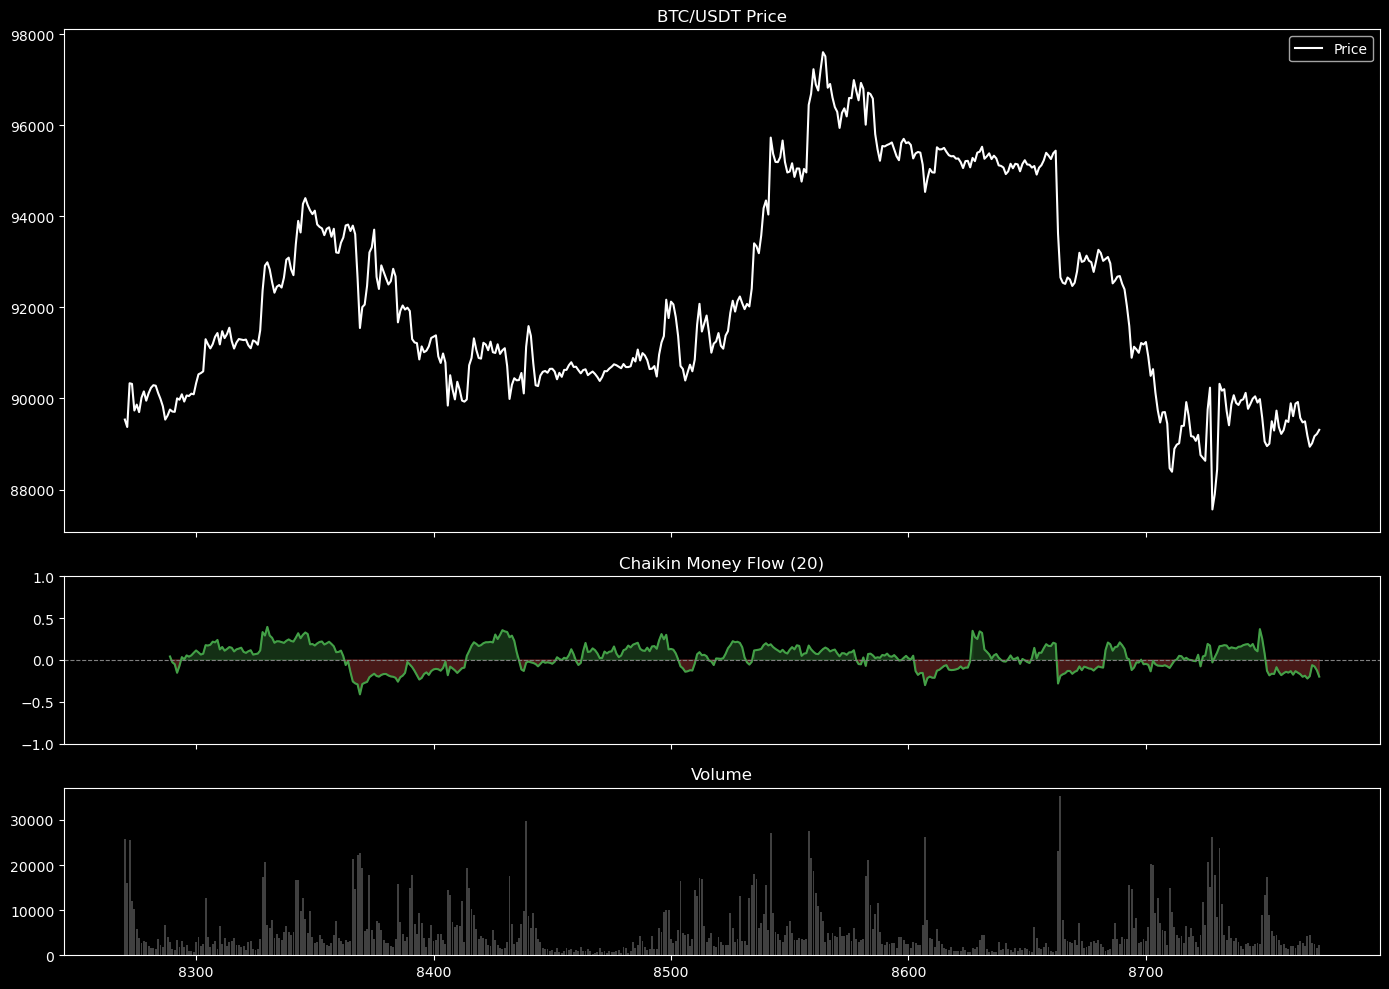

In [12]:
# Plotting
plt.style.use('dark_background')
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})

# 1. Price
axes[0].plot(df.index, df['close'], label='Price', color='white')
axes[0].set_title(f'BTC/USDT Price')
axes[0].legend()

# 2. CMF
axes[1].plot(df.index, df['cmf'], label='CMF (20)', color='#43A047')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].fill_between(df.index, df['cmf'], 0, where=(df['cmf'] >= 0), color='#43A047', alpha=0.3)
axes[1].fill_between(df.index, df['cmf'], 0, where=(df['cmf'] < 0), color='#EF5350', alpha=0.3)
axes[1].set_title('Chaikin Money Flow (20)')
axes[1].set_ylim(-1, 1) # CMF is theoretically bound between -1 and 1

# 3. Volume
axes[2].bar(df.index, df['volume'], color='gray', alpha=0.5, label='Volume')
axes[2].set_title('Volume')

plt.tight_layout()
plt.show()